In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from utils.utils import compute_weighted_returns, portfolio_performance_summary, compute_probability_weighted_returns
from utils.two_state_hmm import *
from utils.cvxpy_portfolio import *
from utils.benchmark_portfolio import *
from utils.three_state_hmm import *
from utils.three_state_portfolio_utils import *

## Set Up DataFrames

In [3]:
insampleRet = pd.read_csv("data/etf_returns_insample.csv", index_col=0, parse_dates=True)
outsampleRet = pd.read_csv("data/etf_returns_outsample.csv", index_col=0, parse_dates=True)
prices = pd.read_csv("data/etf_prices.csv", index_col=0, parse_dates=True) 

In [4]:
insampleRet

,EFA,GLD,HYG,IWM,LQD,QQQ,SPY,TLT
Date,,,,,,,,
2007-04-12,0.006654,-0.001343,0.000671,0.006703,0.001504,0.007886,0.004434,0.000230
2007-04-13,0.003311,0.012609,-0.001821,0.006412,-0.001692,0.002018,0.004552,-0.003095
2007-04-16,0.010496,0.008221,-0.000384,0.013672,0.000847,0.009141,0.009452,0.005495
2007-04-17,0.000126,-0.005865,-0.000480,-0.003036,0.005437,0.002217,0.002655,0.005578
2007-04-18,-0.000378,0.005573,0.000288,-0.005855,0.000281,-0.003327,0.001223,0.004982
...,...,...,...,...,...,...,...,...
2018-12-24,-0.011708,0.010891,-0.007507,-0.019588,-0.002317,-0.025111,-0.026778,0.004957
2018-12-26,0.022938,-0.003004,0.016687,0.046942,-0.000803,0.060567,0.049290,-0.010773
2018-12-27,0.002916,0.007576,-0.000618,0.004160,0.000000,0.003863,0.007648,0.000166


In [5]:
outsampleRet

,EFA,GLD,HYG,IWM,LQD,QQQ,SPY,TLT
Date,,,,,,,,
2019-01-02,-0.002044,0.000660,-0.001357,0.005660,0.003097,0.004011,0.001040,0.005253
2019-01-03,-0.009076,0.009025,0.000494,-0.018059,0.000442,-0.033216,-0.024152,0.011315
2019-01-04,0.030162,-0.008119,0.016644,0.036673,-0.000619,0.041895,0.032947,-0.011642
2019-01-07,0.003832,0.003453,0.009663,0.017343,0.000088,0.011835,0.007854,-0.002952
2019-01-08,0.006464,-0.002712,0.006470,0.015214,0.002207,0.009005,0.009352,-0.002631
...,...,...,...,...,...,...,...,...
2025-12-23,0.006146,0.013165,0.000746,-0.005933,0.000999,0.004672,0.004560,0.001601
2025-12-24,0.001245,-0.004143,0.001862,0.002496,0.003894,0.002921,0.003511,0.006039
2025-12-26,0.001658,0.011609,-0.000496,-0.005118,-0.000090,-0.000064,-0.000101,-0.003300


In [6]:
prices

,EFA,GLD,HYG,IWM,LQD,QQQ,SPY,TLT
Date,,,,,,,,
2007-04-11,44.219486,67.080002,32.021988,62.195038,50.453178,37.935268,101.382812,48.606972
2007-04-12,44.514721,66.989998,32.043484,62.613304,50.529118,38.235592,101.833328,48.618141
2007-04-13,44.662350,67.839996,31.985178,63.016090,50.443680,38.312817,102.297974,48.467907
2007-04-16,45.133610,68.400002,31.972891,63.883556,50.486416,38.664631,103.269440,48.734951
2007-04-17,45.139309,68.000000,31.957552,63.689919,50.761642,38.750435,103.543953,49.007557
...,...,...,...,...,...,...,...,...
2025-12-23,96.290001,413.640015,79.318466,251.632385,108.988869,621.326538,686.086304,86.531952
2025-12-24,96.410004,411.929993,79.466286,252.261276,109.414070,623.144287,688.499695,87.056084
2025-12-26,96.570000,416.739990,79.426857,250.973557,109.404182,623.104309,688.429871,86.769302


## Fit Two-State HMM on SPY

In [7]:
regimeRetIn = insampleRet[["SPY"]]
model, stateDf = fit_two_state_hmm(regimeRetIn)
stateDf, stateMap = relabel_states_by_vol_two_state(stateDf)
summary = summarize_states(model, stateDf)

print("\nMeans learned by model:")
print(model.means_)

print("\nCovariances learned by model:")
print(model.covars_)

print("\nTransition matrix:")
print(model.transmat_)

print("\nState summary:")
print(summary)

plot_regimes(stateDf, output_dir="results", plot_id="insample_two_state_base")

Model is not converging.  Current: 9467.344949044778 is not greater than 9467.524978456817. Delta is -0.18002941203849332



Means learned by model:
[[ 0.00086539]
 [-0.00162138]]

Covariances learned by model:
[[[5.51660034e-05]]

 [[5.02320992e-04]]]

Transition matrix:
[[0.98760015 0.01239985]
 [0.03854529 0.96145471]]

State summary:
   state  n_obs  fraction  mean_return  volatility  annualized_mean_approx  \
0      0   2273  0.769986     0.000848    0.007252                0.213626   
1      1    679  0.230014    -0.001669    0.022396               -0.420667   

   annualized_vol_approx  
0               0.115128  
1               0.355519  


Try to fit another time here with standardization to see if convergence warning can be resolved

In [8]:
modelScaled, stateDfScaled, scaler = fit_two_state_hmm_scaled(regimeRetIn)
stateDfScaled, stateMapScaled = relabel_states_by_vol_two_state(stateDfScaled)
summaryScaled = summarize_states(modelScaled, stateDfScaled)

print("\nMeans learned by model (Scaled):")
print(modelScaled.means_)

print("\nCovariances learned by model (Scaled):")
print(modelScaled.covars_)

print("\nTransition matrix:")
print(modelScaled.transmat_)

print("\nState summary:")
print(summaryScaled)

plot_regimes(stateDfScaled, output_dir="results", plot_id="scaled")


Means learned by model (Scaled):
[[ 0.05983953]
 [-0.13101473]]

Covariances learned by model (Scaled):
[[[0.2576565 ]]

 [[2.60032947]]]

Transition matrix:
[[0.97801836 0.02198164]
 [0.04757167 0.95242833]]

State summary:
   state  n_obs  fraction  mean_return  volatility  annualized_mean_approx  \
0      0   2050  0.694444     0.000949    0.006426                0.239109   
1      1    902  0.305556    -0.001277    0.020406               -0.321767   

   annualized_vol_approx  
0               0.102006  
1               0.323929  


Convergence issue seems to be fixed with standardization, will be using scaled model from this point onward. Visually, there doesn't seem to be much difference, but the calculated values are slightly different.

### Display Intermediate Results

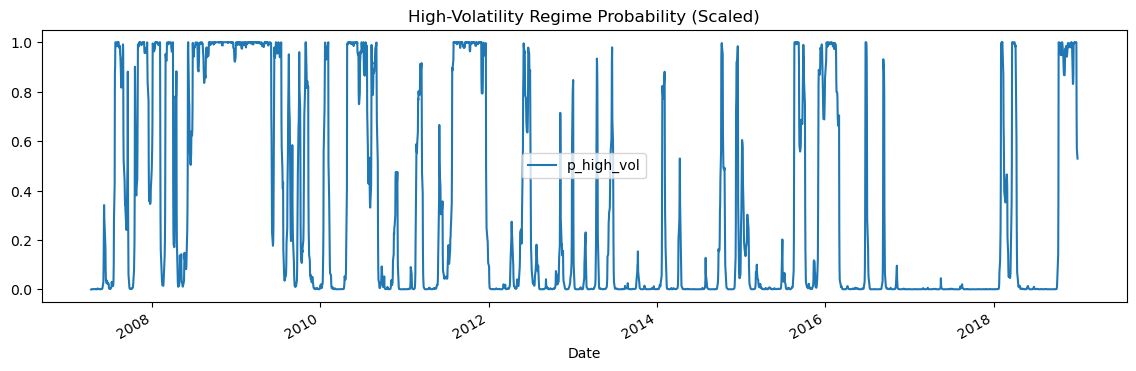

In [9]:
stateDfScaled[["p_high_vol"]].plot(figsize=(14, 4), title="High-Volatility Regime Probability (Scaled)")
plt.show()

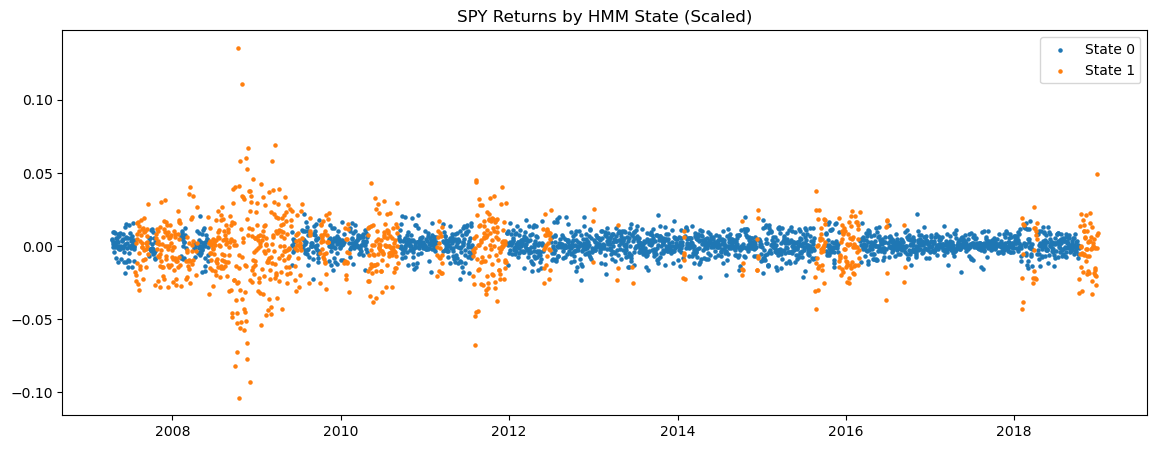

In [10]:
plt.figure(figsize=(14, 5))
for s in [0, 1]:
    mask = stateDfScaled["state"] == s
    plt.scatter(
        stateDfScaled.index[mask],
        stateDfScaled.loc[mask, "SPY_ret"],
        s=5,
        label=f"State {s}"
    )
plt.legend()
plt.title("SPY Returns by HMM State (Scaled)")
plt.show()

Checking 2008-2009 period to see if majority is truly classified as high-volatility, as we would expect.

In [11]:
stateDfScaled.loc["2008-01-01":"2009-06-30", ["SPY_ret", "state", "p_high_vol"]]

,SPY_ret,state,p_high_vol
Date,,,
2008-01-02,-0.008793,1,0.578969
2008-01-03,-0.000483,1,0.676530
2008-01-04,-0.024811,1,0.995011
2008-01-07,-0.000850,1,0.986131
2008-01-08,-0.016280,1,0.989315
...,...,...,...
2009-06-24,0.008582,1,0.983091
2009-06-25,0.021515,1,0.990552
2009-06-26,-0.002610,1,0.960113


In [12]:
stateDfScaled.loc["2008-01-01":"2009-06-30", ["state"]].value_counts()

state
1        312
0         65
Name: count, dtype: int64

## Label ETFs and Report Regime Metrics

In [13]:
#State 0: lower volatility, State 1: higher volatility
regimeLabels = stateDfScaled[["state"]].copy()
inRetLabeled = insampleRet.join(regimeLabels, how="inner")

display(inRetLabeled.head())

,EFA,GLD,HYG,IWM,LQD,QQQ,SPY,TLT,state
Date,,,,,,,,,
2007-04-12,0.006654,-0.001343,0.000671,0.006703,0.001504,0.007886,0.004434,0.000230,0
2007-04-13,0.003311,0.012609,-0.001821,0.006412,-0.001692,0.002018,0.004552,-0.003095,0
2007-04-16,0.010496,0.008221,-0.000384,0.013672,0.000847,0.009141,0.009452,0.005495,0
2007-04-17,0.000126,-0.005865,-0.000480,-0.003036,0.005437,0.002217,0.002655,0.005578,0
2007-04-18,-0.000378,0.005573,0.000288,-0.005855,0.000281,-0.003327,0.001223,0.004982,0


In [14]:
assetCols = [c for c in inRetLabeled.columns if c != "state"]

retRegime0 = inRetLabeled.loc[inRetLabeled["state"] == 0, assetCols].copy()
retRegime1 = inRetLabeled.loc[inRetLabeled["state"] == 1, assetCols].copy()

print("Regime 0 returns shape:", retRegime0.shape)
print("Regime 1 returns shape:", retRegime1.shape)

Regime 0 returns shape: (2050, 8)
Regime 1 returns shape: (902, 8)


In [15]:
cov0 = retRegime0.cov()
cov1 = retRegime1.cov()

In [16]:
cov0

,EFA,GLD,HYG,IWM,LQD,QQQ,SPY,TLT
EFA,7.328145e-05,0.000017,0.000017,0.000055,-2.782587e-08,0.000046,0.000045,-0.000018
GLD,1.696333e-05,0.000087,0.000003,0.000005,6.852611e-06,0.000002,0.000004,0.000012
HYG,1.704874e-05,0.000003,0.000013,0.000017,2.453044e-06,0.000014,0.000014,-0.000002
IWM,5.456939e-05,0.000005,0.000017,0.000084,-3.025179e-06,0.000055,0.000050,-0.000022
LQD,-2.782587e-08,0.000007,0.000002,-0.000003,1.088747e-05,-0.000001,-0.000002,0.000021
QQQ,4.626744e-05,0.000002,0.000014,0.000055,-1.132630e-06,0.000064,0.000045,-0.000016
SPY,4.495018e-05,0.000004,0.000014,0.000050,-1.628822e-06,0.000045,0.000041,-0.000016
TLT,-1.792771e-05,0.000012,-0.000002,-0.000022,2.082296e-05,-0.000016,-0.000016,0.000061


In [17]:
cov1

,EFA,GLD,HYG,IWM,LQD,QQQ,SPY,TLT
EFA,0.000552,2.930236e-05,0.000189,0.000497,3.819775e-05,0.000424,0.000448,-0.000141
GLD,0.000029,2.445389e-04,-0.000010,-0.000002,-8.263547e-07,-0.000007,0.000003,0.000016
HYG,0.000189,-1.036448e-05,0.000153,0.000179,4.291948e-05,0.000150,0.000165,-0.000052
IWM,0.000497,-1.773542e-06,0.000179,0.000593,1.857876e-05,0.000454,0.000464,-0.000149
LQD,0.000038,-8.263547e-07,0.000043,0.000019,6.410234e-05,0.000018,0.000025,0.000020
QQQ,0.000424,-6.567096e-06,0.000150,0.000454,1.775315e-05,0.000431,0.000396,-0.000121
SPY,0.000448,2.528933e-06,0.000165,0.000464,2.549326e-05,0.000396,0.000416,-0.000124
TLT,-0.000141,1.588806e-05,-0.000052,-0.000149,1.998549e-05,-0.000121,-0.000124,0.000134


In [18]:
summary0 = pd.DataFrame({
    "mean_daily": retRegime0.mean(),
    "vol_daily": retRegime0.std(),
    "mean_annual_approx": retRegime0.mean() * 252,
    "vol_annual_approx": retRegime0.std() * np.sqrt(252),
})

summary1 = pd.DataFrame({
    "mean_daily": retRegime1.mean(),
    "vol_daily": retRegime1.std(),
    "mean_annual_approx": retRegime1.mean() * 252,
    "vol_annual_approx": retRegime1.std() * np.sqrt(252),
})

display(summary0)
display(summary1)

,mean_daily,vol_daily,mean_annual_approx,vol_annual_approx
EFA,0.000766,0.008560,0.193120,0.135893
GLD,0.000067,0.009338,0.016830,0.148235
HYG,0.000358,0.003622,0.090221,0.057505
IWM,0.001068,0.009159,0.269047,0.145395
LQD,0.000175,0.003300,0.044079,0.052380
QQQ,0.001254,0.007998,0.316073,0.126958
SPY,0.000949,0.006426,0.239109,0.102006
TLT,-0.000049,0.007816,-0.012414,0.124071


,mean_daily,vol_daily,mean_annual_approx,vol_annual_approx
EFA,-0.001661,0.023493,-0.418525,0.372932
GLD,0.000504,0.015638,0.127133,0.248241
HYG,-0.000210,0.012384,-0.052943,0.196585
IWM,-0.001677,0.024348,-0.422591,0.386508
LQD,0.000209,0.008006,0.052741,0.127098
QQQ,-0.001345,0.020758,-0.339064,0.329525
SPY,-0.001277,0.020406,-0.321767,0.323929
TLT,0.000900,0.011579,0.226739,0.183812


## Portfolio Construction

In [19]:
inRegimeWeights0 = solve_min_variance_portfolio(cov0)
inRegimeWeights1 = solve_min_variance_portfolio(cov1)

print("Regime 0 weights:")
print(inRegimeWeights0.sort_values(ascending=False))

print("\nRegime 1 weights:")
print(inRegimeWeights1.sort_values(ascending=False))

Set parameter Username
Set parameter LicenseID to value 2768137
Academic license - for non-commercial use only - expires 2027-01-21
Regime 0 weights:
LQD    5.600703e-01
HYG    3.424751e-01
SPY    7.581191e-02
GLD    2.163137e-02
QQQ    6.865342e-06
IWM    3.790868e-06
TLT    3.442912e-07
EFA    3.037214e-07
dtype: float64

Regime 1 weights:
TLT    3.519549e-01
LQD    2.630090e-01
HYG    1.555083e-01
GLD    1.198158e-01
QQQ    9.088865e-02
IWM    1.879923e-02
SPY    2.405133e-05
EFA    8.913013e-08
dtype: float64


In [20]:
inWeightsDf = pd.DataFrame({
    "Regime_0": inRegimeWeights0,
    "Regime_1": inRegimeWeights1
})

inWeightsDf

,Regime_0,Regime_1
EFA,3.037214e-07,8.913013e-08
GLD,2.163137e-02,1.198158e-01
HYG,3.424751e-01,1.555083e-01
IWM,3.790868e-06,1.879923e-02
LQD,5.600703e-01,2.630090e-01
QQQ,6.865342e-06,9.088865e-02
SPY,7.581191e-02,2.405133e-05
TLT,3.442912e-07,3.519549e-01


<Axes: title={'center': 'Portfolio Weights by Regime (Min-Var)'}>

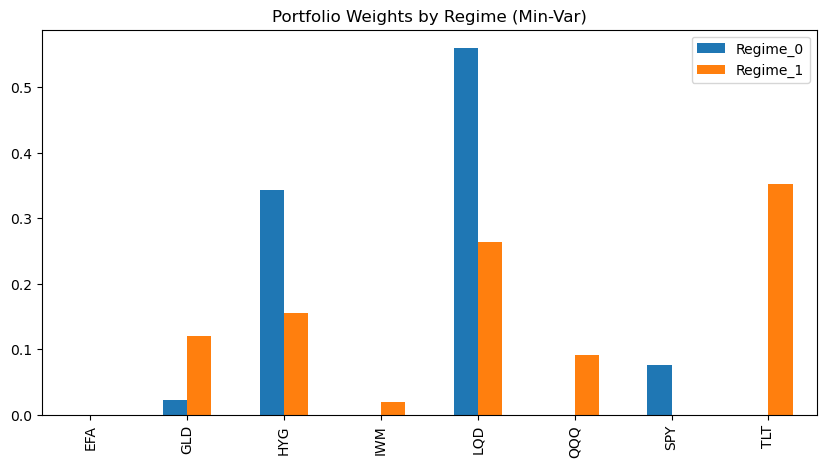

In [21]:
inWeightsDf.plot(kind="bar", figsize=(10, 5), title="Portfolio Weights by Regime (Min-Var)")

In [22]:
inPortStats0 = portfolio_stats(inRegimeWeights0, retRegime0)
inPortStats1 = portfolio_stats(inRegimeWeights1, retRegime1)

statsDf = pd.DataFrame({
    "Regime_0": inPortStats0,
    "Regime_1": inPortStats1
})
statsDf

,Regime_0,Regime_1
mean_daily,0.000294,0.000246
vol_daily,0.002639,0.005695
mean_annual_approx,0.074080,0.061904
vol_annual_approx,0.041888,0.090404
sharpe_approx,1.768544,0.684742


In [23]:
inRegimeMeanVarWeights0 = solve_mean_variance_portfolio(retRegime0.mean(), cov0)
inRegimeMeanVarWeights1 = solve_mean_variance_portfolio(retRegime1.mean(), cov1)

inWeightsMeanVarDf = pd.DataFrame({
    "Regime_0": inRegimeMeanVarWeights0,
    "Regime_1": inRegimeWeights1
})

inWeightsMeanVarDf

,Regime_0,Regime_1
EFA,-4.043792e-23,8.913013e-08
GLD,-6.545934e-24,1.198158e-01
HYG,-3.356767e-23,1.555083e-01
IWM,-5.593898e-24,1.879923e-02
LQD,1.427432e-02,2.630090e-01
QQQ,5.000000e-01,9.088865e-02
SPY,4.258203e-01,2.405133e-05
TLT,5.990534e-02,3.519549e-01


<Axes: title={'center': 'Portfolio Weights by Regime (Mean-Variance)'}>

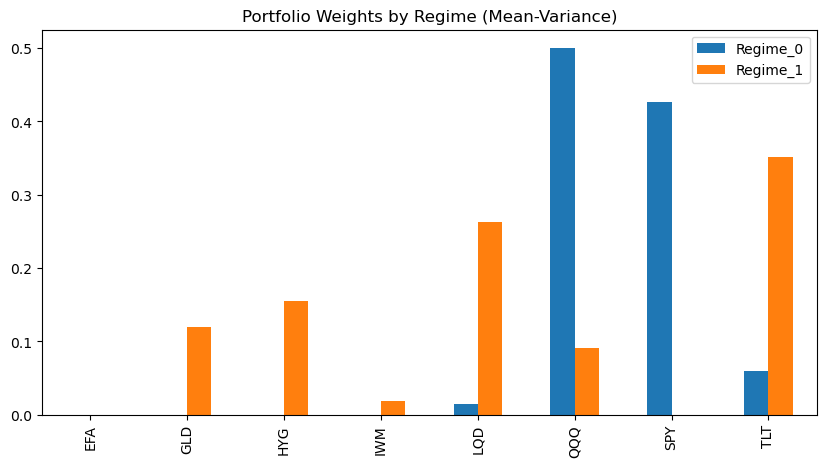

In [24]:
inWeightsMeanVarDf.plot(kind="bar", figsize=(10, 5), title="Portfolio Weights by Regime (Mean-Variance)")

In [25]:
inPortStatsMeanVar0 = portfolio_stats(inRegimeMeanVarWeights0, retRegime0)
inPortStatsMeanVar1 = portfolio_stats(inRegimeMeanVarWeights1, retRegime1)

statsMeanVarDf = pd.DataFrame({
    "Regime_0": inPortStatsMeanVar0,
    "Regime_1": inPortStatsMeanVar1
})
statsMeanVarDf

,Regime_0,Regime_1
mean_daily,0.001031,0.000521
vol_daily,0.006392,0.006635
mean_annual_approx,0.259739,0.131411
vol_annual_approx,0.101477,0.105333
sharpe_approx,2.559591,1.247568


## Backtesting (Mean-Variance)

In [26]:
# modelScaled is fitted model on insample data, scaler is the fitted scaler on insample data, outsampleRet[["SPY"]] is the SPY returns from outsample data
# stateMapScaled is the mapping from raw state labels to volatility-based state labels learned from insample data, returned above
outsampleStateRaw = classify_outsample_two_state(modelScaled, scaler, outsampleRet[["SPY"]])
outsampleState = apply_state_map(outsampleStateRaw, stateMapScaled)

outsampleState.head()

,SPY_ret,state_raw,p_state_0,p_state_1,state,p_low_vol,p_high_vol
Date,,,,,,,
2019-01-02,0.001040,0,1.000000,5.975118e-39,0,1.000000,5.975118e-39
2019-01-03,-0.024152,1,0.002469,9.975311e-01,1,0.002469,9.975311e-01
2019-01-04,0.032947,1,0.000073,9.999267e-01,1,0.000073,9.999267e-01
2019-01-07,0.007854,0,0.506565,4.934353e-01,0,0.506565,4.934353e-01
2019-01-08,0.009352,0,0.755121,2.448794e-01,0,0.755121,2.448794e-01


In [27]:
outsampleState["state"].value_counts()

state
0    1218
1     541
Name: count, dtype: int64

<Axes: title={'center': 'Out-of-Sample High-Vol Probability'}, xlabel='Date'>

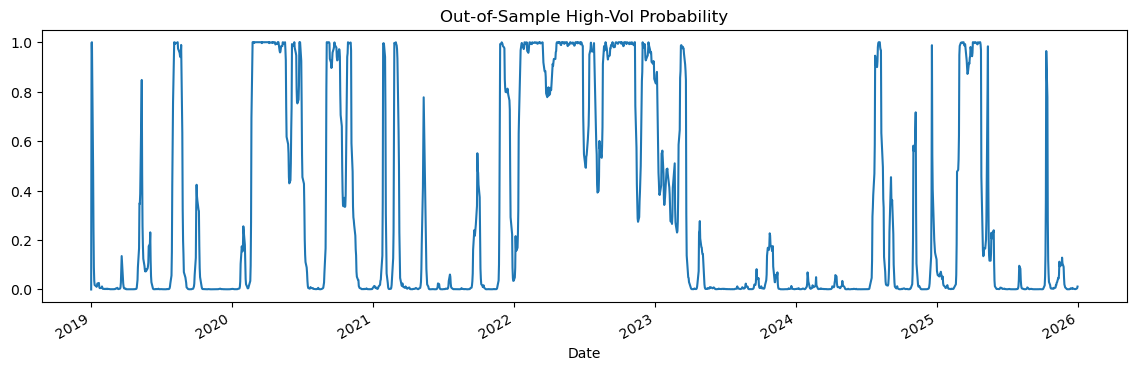

In [28]:
outsampleState["p_high_vol"].plot(figsize=(14,4), title="Out-of-Sample High-Vol Probability")

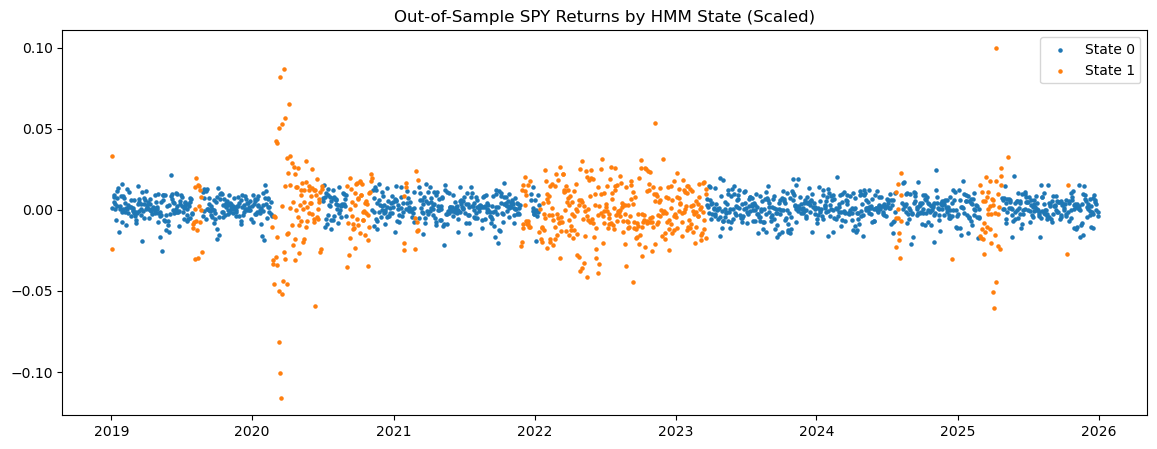

In [29]:
plt.figure(figsize=(14, 5))
for s in [0, 1]:
    mask = outsampleState["state"] == s
    plt.scatter(
        outsampleState.index[mask],
        outsampleState.loc[mask, "SPY_ret"],
        s=5,
        label=f"State {s}"
    )
plt.legend()
plt.title("Out-of-Sample SPY Returns by HMM State (Scaled)")
plt.show()

In [30]:
# Checking COVID period
outsampleState.loc["2020-02-01":"2020-06-30", ["SPY_ret", "state", "p_high_vol"]]

,SPY_ret,state,p_high_vol
Date,,,
2020-02-03,0.007401,0,0.201214
2020-02-04,0.015126,0,0.180514
2020-02-05,0.011482,0,0.111296
2020-02-06,0.003359,0,0.042492
2020-02-07,-0.005344,0,0.021002
...,...,...,...
2020-06-24,-0.025840,1,0.999612
2020-06-25,0.010664,1,0.998147
2020-06-26,-0.024038,1,0.999525


In [31]:
# COVID period state counts
outsampleState.loc["2020-02-01":"2020-06-30", ["state"]].value_counts()

state
1        91
0        13
Name: count, dtype: int64

In [32]:
outsampleRetRegime = outsampleRet.join(outsampleState[["state"]], how="inner")

outsampleRetRegime

,EFA,GLD,HYG,IWM,LQD,QQQ,SPY,TLT,state
Date,,,,,,,,,
2019-01-02,-0.002044,0.000660,-0.001357,0.005660,0.003097,0.004011,0.001040,0.005253,0
2019-01-03,-0.009076,0.009025,0.000494,-0.018059,0.000442,-0.033216,-0.024152,0.011315,1
2019-01-04,0.030162,-0.008119,0.016644,0.036673,-0.000619,0.041895,0.032947,-0.011642,1
2019-01-07,0.003832,0.003453,0.009663,0.017343,0.000088,0.011835,0.007854,-0.002952,0
2019-01-08,0.006464,-0.002712,0.006470,0.015214,0.002207,0.009005,0.009352,-0.002631,0
...,...,...,...,...,...,...,...,...,...
2025-12-23,0.006146,0.013165,0.000746,-0.005933,0.000999,0.004672,0.004560,0.001601,0
2025-12-24,0.001245,-0.004143,0.001862,0.002496,0.003894,0.002921,0.003511,0.006039,0
2025-12-26,0.001658,0.011609,-0.000496,-0.005118,-0.000090,-0.000064,-0.000101,-0.003300,0


In [33]:
regimeRetOut = compute_weighted_returns(outsampleRet,outsampleState["state"], inRegimeMeanVarWeights0, inRegimeMeanVarWeights1)

regimeRetOut

,state,portfolio_return
date,,
2019-01-02,0,0.002807
2019-01-03,1,0.007166
2019-01-04,1,-0.004110
2019-01-07,0,0.009086
2019-01-08,0,0.008358
...,...,...
2025-12-23,0,0.004388
2025-12-24,0,0.003373
2025-12-26,0,-0.000274


In [34]:
# Create mean-variance benchmark portfolio using full insample returns (not regime-specific)
cov_insample = insampleRet.cov()
mu_insample = insampleRet.mean()

staticWeights = solve_mean_variance_portfolio(mu_insample, cov_insample, max_weight=0.5)
staticWeights

EFA    3.479054e-23
GLD    9.403465e-02
HYG    1.076653e-01
IWM    1.651100e-23
LQD    2.907685e-01
QQQ    2.125070e-01
SPY    2.284025e-23
TLT    2.950245e-01
Name: weight, dtype: float64

In [35]:
equallyWeighted = equal_weight_returns(outsampleRet)
staticWeighted = fixed_weight_returns(outsampleRet, staticWeights, name="static_portfolio")
regimeWeighted = regimeRetOut["portfolio_return"].rename("regime_switching")

In [36]:
backtestDf = pd.concat([regimeWeighted, equallyWeighted, staticWeighted], axis=1).dropna()
backtestDf

,regime_switching,equal_weight,static_portfolio
2019-01-02,0.002807,0.002040,0.003219
2019-01-03,0.007166,-0.007903,-0.002690
2019-01-04,-0.004110,0.017243,0.006317
2019-01-07,0.009086,0.006389,0.003035
2019-01-08,0.008358,0.005421,0.002221
...,...,...,...
2025-12-23,0.004388,0.003245,0.003074
2025-12-24,0.003373,0.002228,0.003345
2025-12-26,-0.000274,0.000512,0.000025
2025-12-29,-0.003702,-0.007075,-0.003675


<Axes: title={'center': 'Out-of-Sample Cumulative Performance'}>

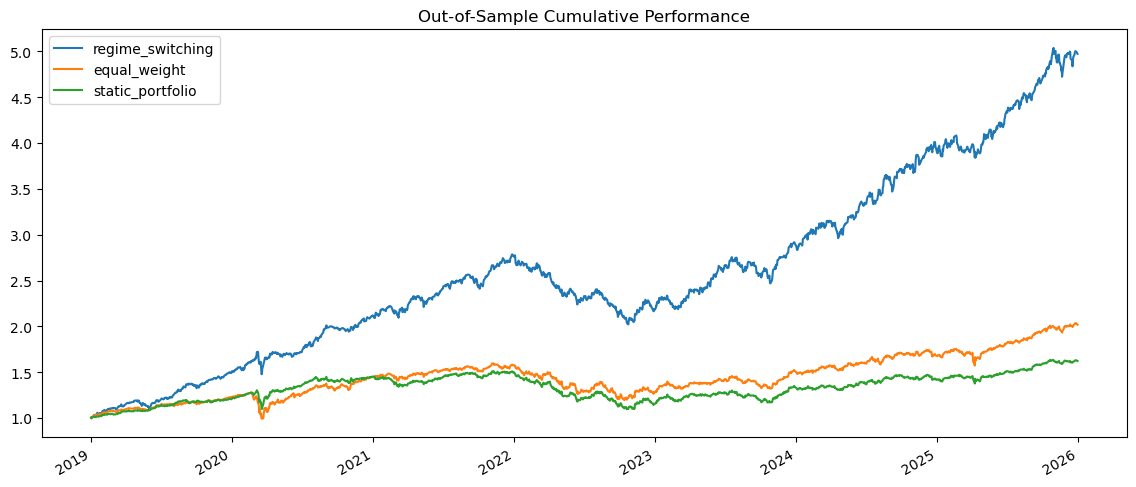

In [37]:
cumulativeDf = np.exp(backtestDf.cumsum())
cumulativeDf.plot(figsize=(14,6), title="Out-of-Sample Cumulative Performance")

In [38]:
performanceSummary = pd.DataFrame({
    "Regime Switching": portfolio_performance_summary(backtestDf["regime_switching"]),
    "Equal Weight": portfolio_performance_summary(backtestDf["equal_weight"]),
    "Static Portfolio": portfolio_performance_summary(backtestDf["static_portfolio"])
})

performanceSummary = performanceSummary.T
performanceSummary

,mean_daily,vol_daily,annualized_return_approx,annualized_vol_approx,sharpe_approx,max_drawdown,total_return
Regime Switching,0.000912,0.008080,0.229772,0.128272,1.791287,-0.274275,3.972106
Equal Weight,0.000399,0.007867,0.100586,0.124882,0.805450,-0.250046,1.017998
Static Portfolio,0.000275,0.006468,0.069302,0.102673,0.674981,-0.275265,0.622129


In [39]:
regimeRetOut["state_change"] = regimeRetOut["state"].diff().ne(0).astype(int)
n_switches = regimeRetOut["state_change"].sum()
print("Number of regime switches:", n_switches)

Number of regime switches: 27


### Implement One-Day Lag to Prevent Look-Ahead Bias

In [40]:
laggedStates = regimeRetOut["state"].shift(1).dropna()
outsampleRetLagged = outsampleRet.loc[laggedStates.index]
regimeRetOutLagged = compute_weighted_returns(outsampleRetLagged, laggedStates, inRegimeMeanVarWeights0, inRegimeMeanVarWeights1)

regimeWeightedLagged = regimeRetOutLagged["portfolio_return"].rename("regime_switching_lagged")

In [41]:
equallyWeightedLagged = equallyWeighted.loc[regimeRetOutLagged.index]
staticWeightedLagged = staticWeighted.loc[regimeRetOutLagged.index]

In [42]:
backtestDfLagged = pd.concat([regimeWeightedLagged, equallyWeightedLagged, staticWeightedLagged], axis=1, sort=True).dropna()
backtestDfLagged

,regime_switching_lagged,equal_weight,static_portfolio
date,,,
2019-01-03,-0.026208,-0.007903,-0.002690
2019-01-04,-0.004110,0.017243,0.006317
2019-01-07,0.000828,0.006389,0.003035
2019-01-08,0.008358,0.005421,0.002221
2019-01-09,0.006004,0.005248,0.003093
...,...,...,...
2025-12-23,0.004388,0.003245,0.003074
2025-12-24,0.003373,0.002228,0.003345
2025-12-26,-0.000274,0.000512,0.000025


<Axes: title={'center': 'Out-of-Sample Cumulative Performance (With 1-Day Lag)'}, xlabel='date'>

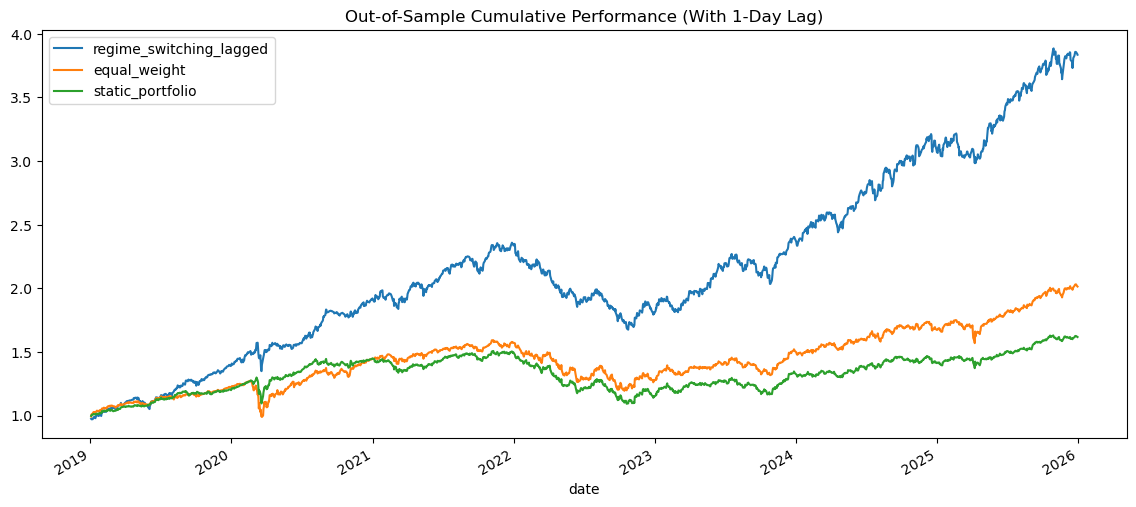

In [43]:
cumulativeDfLagged = np.exp(backtestDfLagged.cumsum())
cumulativeDfLagged.plot(figsize=(14,6), title="Out-of-Sample Cumulative Performance (With 1-Day Lag)")

In [44]:
performanceSummaryLagged = pd.DataFrame({
    "Regime Switching": portfolio_performance_summary(backtestDfLagged["regime_switching_lagged"]),
    "Equal Weight": portfolio_performance_summary(backtestDfLagged["equal_weight"]),
    "Static Portfolio": portfolio_performance_summary(backtestDfLagged["static_portfolio"])
})

performanceSummaryLagged = performanceSummaryLagged.T
performanceSummaryLagged

,mean_daily,vol_daily,annualized_return_approx,annualized_vol_approx,sharpe_approx,max_drawdown,total_return
Regime Switching,0.000765,0.008300,0.192725,0.131754,1.462763,-0.289894,2.836215
Equal Weight,0.000398,0.007869,0.100351,0.124916,0.803348,-0.250046,1.013885
Static Portfolio,0.000273,0.006469,0.068880,0.102696,0.670720,-0.275265,0.616917


## Probability-Weighted Portfolio

In [45]:
laggedProbs = outsampleState[["p_low_vol", "p_high_vol"]].shift(1).dropna()
probRetOutLagged = outsampleRet.loc[laggedProbs.index]

In [46]:
regimeProbLagged = compute_probability_weighted_returns(probRetOutLagged, laggedProbs, inRegimeMeanVarWeights0, inRegimeMeanVarWeights1)
regimeProbabilityWeightedLagged = regimeProbLagged["portfolio_return"].rename("prob_weighted")

In [47]:
backtestDf = pd.concat([regimeWeightedLagged, regimeProbabilityWeightedLagged, equallyWeightedLagged, staticWeightedLagged], axis=1).dropna()
backtestDf

,regime_switching_lagged,prob_weighted,equal_weight,static_portfolio
date,,,,
2019-01-03,-0.026208,-0.026208,-0.007903,-0.002690
2019-01-04,-0.004110,-0.004015,0.017243,0.006317
2019-01-07,0.000828,0.000828,0.006389,0.003035
2019-01-08,0.008358,0.004148,0.005421,0.002221
2019-01-09,0.006004,0.004791,0.005248,0.003093
...,...,...,...,...
2025-12-23,0.004388,0.004386,0.003245,0.003074
2025-12-24,0.003373,0.003373,0.002228,0.003345
2025-12-26,-0.000274,-0.000274,0.000512,0.000025


<Axes: title={'center': 'Strategy Comparison'}, xlabel='date'>

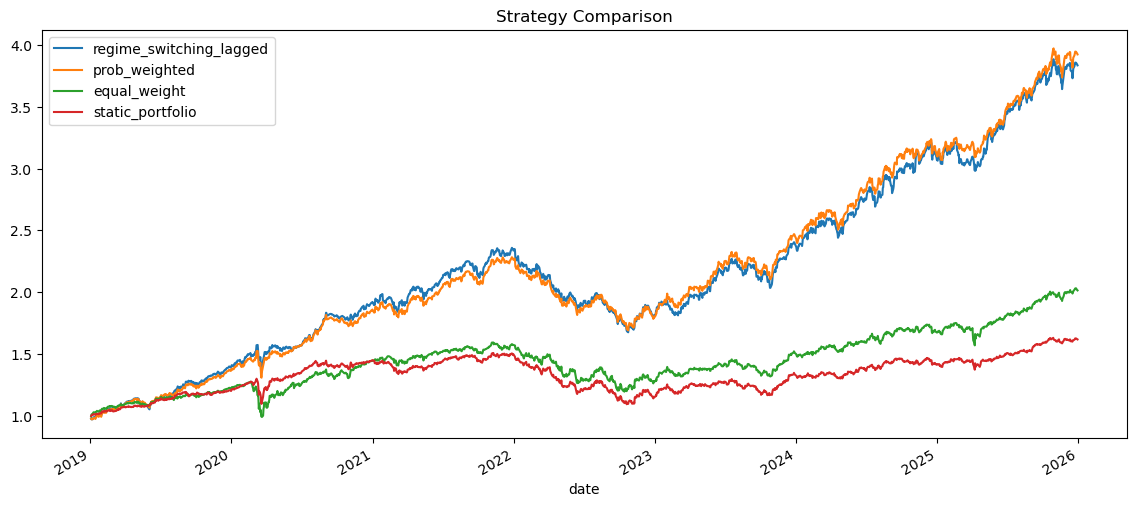

In [48]:
cum_df = np.exp(backtestDf.cumsum())
cum_df.plot(figsize=(14,6), title="Strategy Comparison")

In [49]:
performanceSummaryFull = pd.DataFrame({
    col: portfolio_performance_summary(backtestDf[col])
    for col in backtestDf.columns
}).T

performanceSummaryFull

,mean_daily,vol_daily,annualized_return_approx,annualized_vol_approx,sharpe_approx,max_drawdown,total_return
regime_switching_lagged,0.000765,0.008300,0.192725,0.131754,1.462763,-0.289894,2.836215
prob_weighted,0.000778,0.007769,0.195995,0.123329,1.589204,-0.259338,2.924727
equal_weight,0.000398,0.007869,0.100351,0.124916,0.803348,-0.250046,1.013885
static_portfolio,0.000273,0.006469,0.068880,0.102696,0.670720,-0.275265,0.616917


## Three-State HMM

In [50]:
modelThreeState, threeStateDf, scaler3 = fit_three_state_hmm(regimeRetIn)
threeStateDf, threeStateMap = relabel_three_states_by_vol(threeStateDf)
summaryThreeState = summarize_states(modelThreeState, threeStateDf)

print("\nMeans learned by model (3-State):")
print(modelThreeState.means_)

print("\nCovariances learned by model (3-State):")
print(modelThreeState.covars_)

print("\nTransition matrix:")
print(modelThreeState.transmat_)

print("\nState summary:")
print(summaryThreeState)

plot_regimes(threeStateDf, output_dir="results", plot_id="3-State")


Means learned by model (3-State):
[[-0.0341016 ]
 [ 0.07135309]
 [-0.18233738]]

Covariances learned by model (3-State):
[[[0.85733721]]

 [[0.15442035]]

 [[5.46493171]]]

Transition matrix:
[[9.57325221e-01 3.68331032e-02 5.84167579e-03]
 [3.51701077e-02 9.64829861e-01 3.18113313e-08]
 [2.30993192e-02 1.13804669e-21 9.76900681e-01]]

State summary:
   state  n_obs  fraction  mean_return  volatility  annualized_mean_approx  \
0      0   1419  0.480691     0.001120    0.005032                0.282251   
1      1   1251  0.423780    -0.000174    0.011834               -0.043939   
2      2    282  0.095528    -0.002049    0.029776               -0.516337   

   annualized_vol_approx  
0               0.079886  
1               0.187854  
2               0.472672  


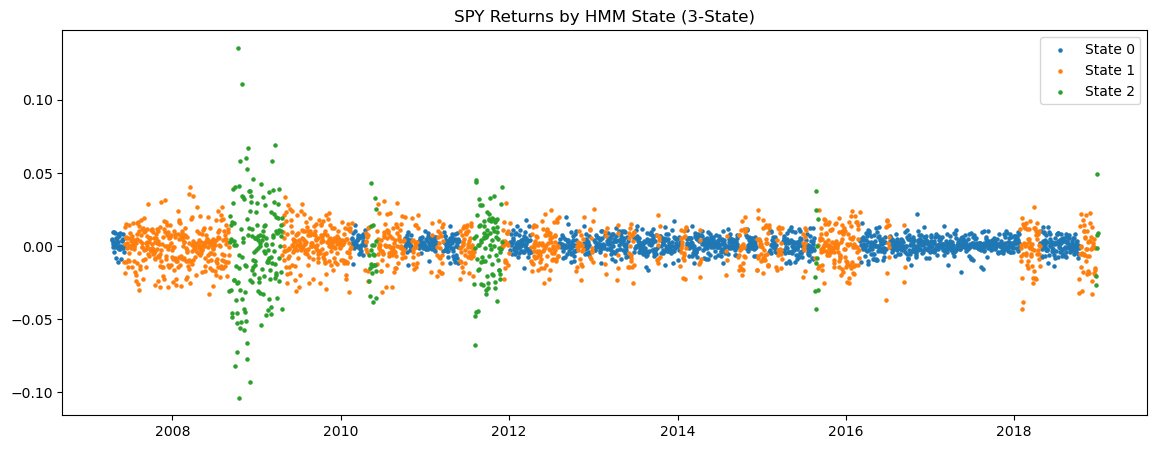

In [51]:
plt.figure(figsize=(14, 5))
for s in [0, 1, 2]:
    mask = threeStateDf["state"] == s
    plt.scatter(
        threeStateDf.index[mask],
        threeStateDf.loc[mask, "SPY_ret"],
        s=5,
        label=f"State {s}"
    )
plt.legend()
plt.title("SPY Returns by HMM State (3-State)")
plt.show()

In [52]:
regimeLabels3 = threeStateDf[["state"]].copy()
threeStateInRet = insampleRet.join(regimeLabels3, how="inner")

asset_cols = [c for c in threeStateInRet.columns if c != "state"]

lowRegimeRet = threeStateInRet.loc[threeStateInRet["state"] == 0, asset_cols]
medRegimeRet = threeStateInRet.loc[threeStateInRet["state"] == 1, asset_cols]
highRegimeRet = threeStateInRet.loc[threeStateInRet["state"] == 2, asset_cols]

In [53]:
lowRegimeMu, cov_low = lowRegimeRet.mean(), lowRegimeRet.cov()
medRegimeMu, cov_med = medRegimeRet.mean(), medRegimeRet.cov()
highRegimeMu, cov_high = highRegimeRet.mean(), highRegimeRet.cov()

In [54]:
lowRegimeWeights = solve_mean_variance_portfolio(lowRegimeMu, cov_low, risk_aversion=10.0, max_weight=0.5)
medRegimeWeights = solve_mean_variance_portfolio(medRegimeMu, cov_med, risk_aversion=10.0, max_weight=0.5)
highRegimeWeights = solve_mean_variance_portfolio(highRegimeMu, cov_high, risk_aversion=10.0, max_weight=0.5)

threeStateWeights = pd.DataFrame({
    "LowVol": lowRegimeWeights,
    "MidVol": medRegimeWeights,
    "HighVol": highRegimeWeights
})
threeStateWeights

,LowVol,MidVol,HighVol
EFA,1.160412e-23,-2.067361e-23,-2.872025e-23
GLD,-1.596052e-22,9.814248e-02,1.803572e-01
HYG,-1.890202e-22,3.385729e-01,8.157313e-02
IWM,-3.845111e-17,-5.684393e-23,-2.110338e-23
LQD,-1.917396e-22,2.597217e-01,1.832090e-01
QQQ,5.000000e-01,-7.303008e-23,5.486073e-02
SPY,5.000000e-01,-5.641055e-23,-1.372840e-23
TLT,-2.274381e-22,3.035629e-01,5.000000e-01


<Axes: title={'center': 'Portfolio Weights by Regime (Mean-Variance, 3-State)'}>

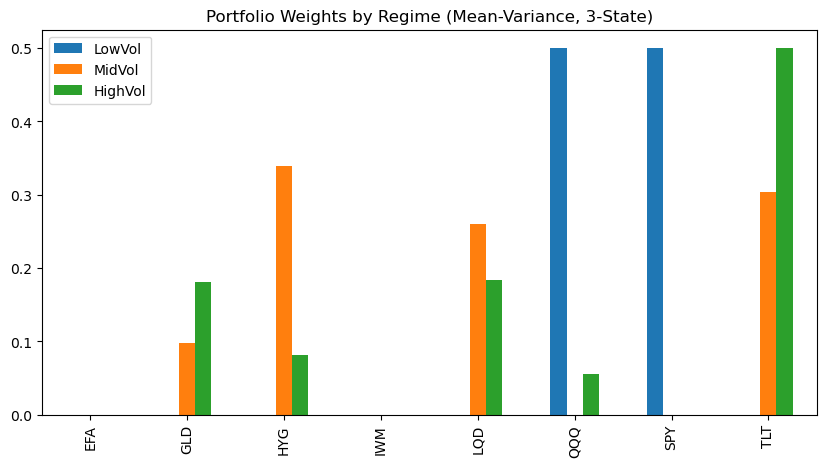

In [55]:
threeStateWeights.plot(kind="bar", figsize=(10, 5), title="Portfolio Weights by Regime (Mean-Variance, 3-State)")

In [56]:
outsampleThreeStatesRaw = classify_outsample_regimes_nstate(modelThreeState, scaler3, outsampleRet[["SPY"]], n_states=3)
outsampleThreeStates = apply_three_state_mapping(outsampleThreeStatesRaw, threeStateMap)

In [57]:
threeStateLagged = outsampleThreeStates["state"].shift(1).dropna()
laggedThreeStateOut = outsampleRet.loc[threeStateLagged.index]

In [58]:
regimeWeightedThreeState = compute_three_state_weighted_returns(
    laggedThreeStateOut,
    threeStateLagged,
    lowRegimeWeights,
    medRegimeWeights,
    highRegimeWeights
)
regimeWeightedThreeState = regimeWeightedThreeState["portfolio_return"].rename("regime_switching_3state")

In [59]:
laggedThreeStateProb = outsampleThreeStates[["p_low_vol", "p_mid_vol", "p_high_vol"]].shift(1).dropna()
probRetOutLagged3 = outsampleRet.loc[laggedThreeStateProb.index]

probWeightedThreeState = compute_three_state_probability_weighted_returns(
    probRetOutLagged3,
    laggedThreeStateProb,
    lowRegimeWeights,
    medRegimeWeights,
    highRegimeWeights
)

probWeightedThreeState = probWeightedThreeState["portfolio_return"].rename("prob_weighted_3state")

In [60]:
comparisonDf = pd.concat([
    regimeWeightedLagged.rename("regime_switching_2state"),
    regimeProbabilityWeightedLagged.rename("prob_weighted_2state"),
    regimeWeightedThreeState,
    probWeightedThreeState,
    equallyWeightedLagged.rename("equal_weight"),
    staticWeightedLagged.rename("static_portfolio")
], axis=1).dropna()

In [61]:
performanceComparison = pd.DataFrame({
    col: portfolio_performance_summary(comparisonDf[col])
    for col in comparisonDf.columns
}).T

performanceComparison

,mean_daily,vol_daily,annualized_return_approx,annualized_vol_approx,sharpe_approx,max_drawdown,total_return
regime_switching_2state,0.000765,0.008300,0.192725,0.131754,1.462763,-0.289894,2.836215
prob_weighted_2state,0.000778,0.007769,0.195995,0.123329,1.589204,-0.259338,2.924727
regime_switching_3state,0.000579,0.006872,0.145808,0.109090,1.336585,-0.254901,1.765403
prob_weighted_3state,0.000650,0.006413,0.163882,0.101799,1.609851,-0.253184,2.137012
equal_weight,0.000398,0.007869,0.100351,0.124916,0.803348,-0.250046,1.013885
static_portfolio,0.000273,0.006469,0.068880,0.102696,0.670720,-0.275265,0.616917


<Axes: title={'center': '2-State vs 3-State Comparison'}, xlabel='date'>

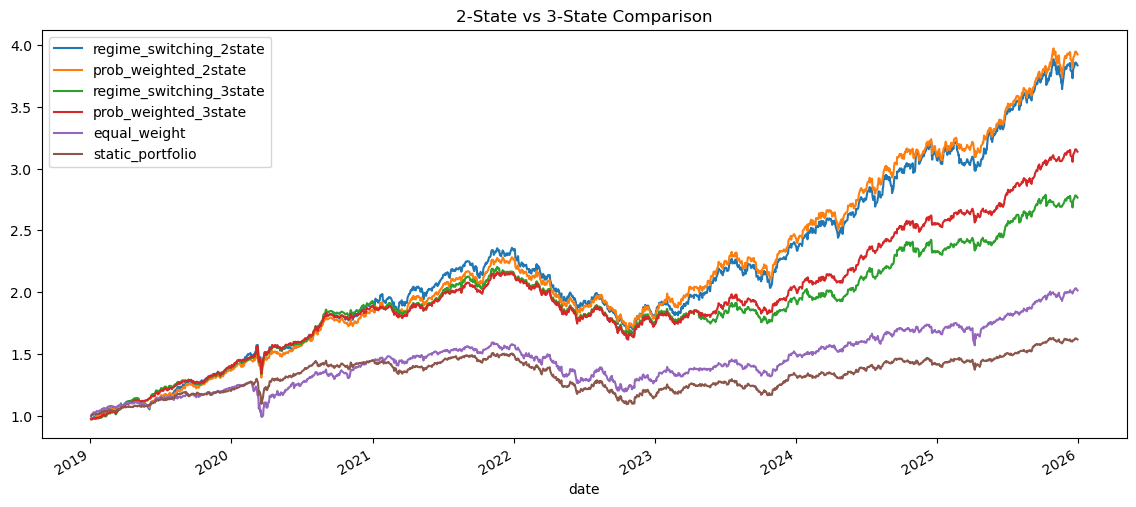

In [62]:
np.exp(comparisonDf.cumsum()).plot(figsize=(14,6), title="2-State vs 3-State Comparison")

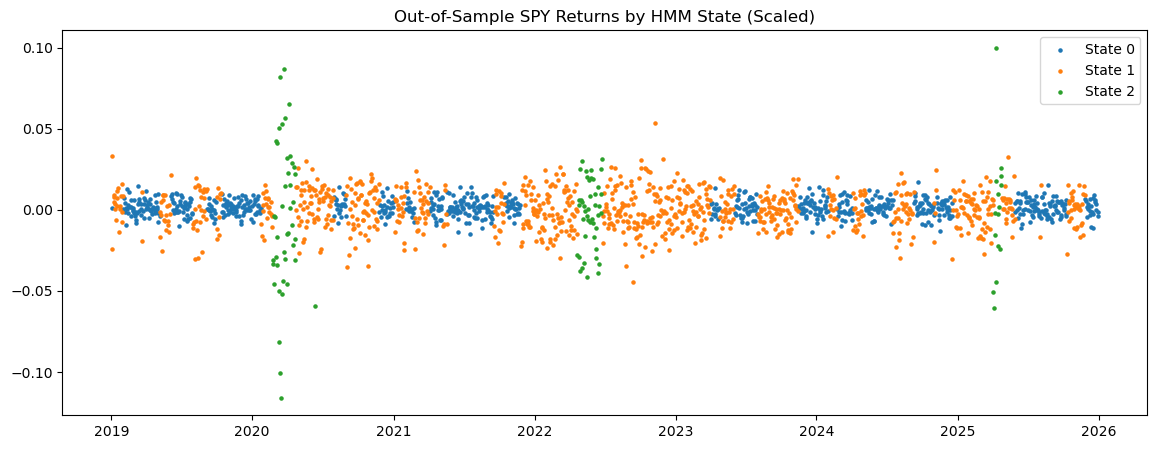

In [65]:
plt.figure(figsize=(14, 5))
for s in [0, 1, 2]:
    mask = outsampleThreeStates["state"] == s
    plt.scatter(
        outsampleThreeStates.index[mask],
        outsampleThreeStates.loc[mask, "SPY_ret"],
        s=5,
        label=f"State {s}"
    )
plt.legend()
plt.title("Out-of-Sample SPY Returns by HMM State (Scaled)")
plt.show()

In [67]:
performanceComparison.round(4)

,mean_daily,vol_daily,annualized_return_approx,annualized_vol_approx,sharpe_approx,max_drawdown,total_return
regime_switching_2state,0.0008,0.0083,0.1927,0.1318,1.4628,-0.2899,2.8362
prob_weighted_2state,0.0008,0.0078,0.1960,0.1233,1.5892,-0.2593,2.9247
regime_switching_3state,0.0006,0.0069,0.1458,0.1091,1.3366,-0.2549,1.7654
prob_weighted_3state,0.0007,0.0064,0.1639,0.1018,1.6099,-0.2532,2.1370
equal_weight,0.0004,0.0079,0.1004,0.1249,0.8033,-0.2500,1.0139
static_portfolio,0.0003,0.0065,0.0689,0.1027,0.6707,-0.2753,0.6169
